# LightGBM analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
predictions = pd.read_csv("../results/lightgbm/lightgbm_predictions.csv", parse_dates=["date"])
results = pd.read_csv("../results/lightgbm/lightgbm_predictions.csv")
feature_importances = pd.read_csv("../results/lightgbm/lightgbm_feature_importances.csv")

### Average feature importance

In [9]:
importance_summary = (
    feature_importances
    .groupby("feature")["importance"]
    .agg(
        mean="mean",
        std="std",
        min="min",
        max="max",
    )
)

importance_summary = (
    importance_summary
    .sort_values(
        "mean",
        ascending=False,
    )
)

importance_summary

,mean,std,min,max
feature,,,,
vix,189.00,34.185767,169,240
volatility_20d,157.25,37.827459,115,197
volatility_10d,125.25,28.335784,93,162
yield_curve,98.75,8.845903,86,106
volatility_5d,97.25,15.649814,80,111
return_5d,84.25,13.937360,69,102
vix_vs_realized_vol,83.75,24.958299,58,117
treasury_10y,83.00,13.589211,72,101
vix_change_5d,78.00,8.082904,71,89


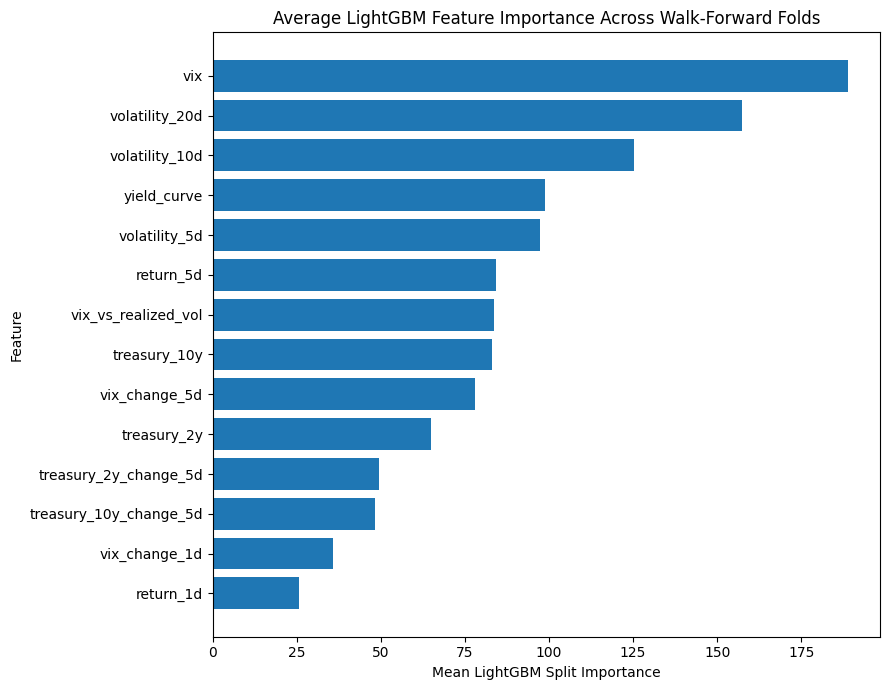

In [10]:
plot_data = (
    importance_summary
    .sort_values("mean")
)

plt.figure(figsize=(9, 7))

plt.barh(
    plot_data.index,
    plot_data["mean"],
)

plt.xlabel("Mean LightGBM Split Importance")
plt.ylabel("Feature")

plt.title(
    "Average LightGBM Feature Importance "
    "Across Walk-Forward Folds"
)

plt.tight_layout()
plt.show()

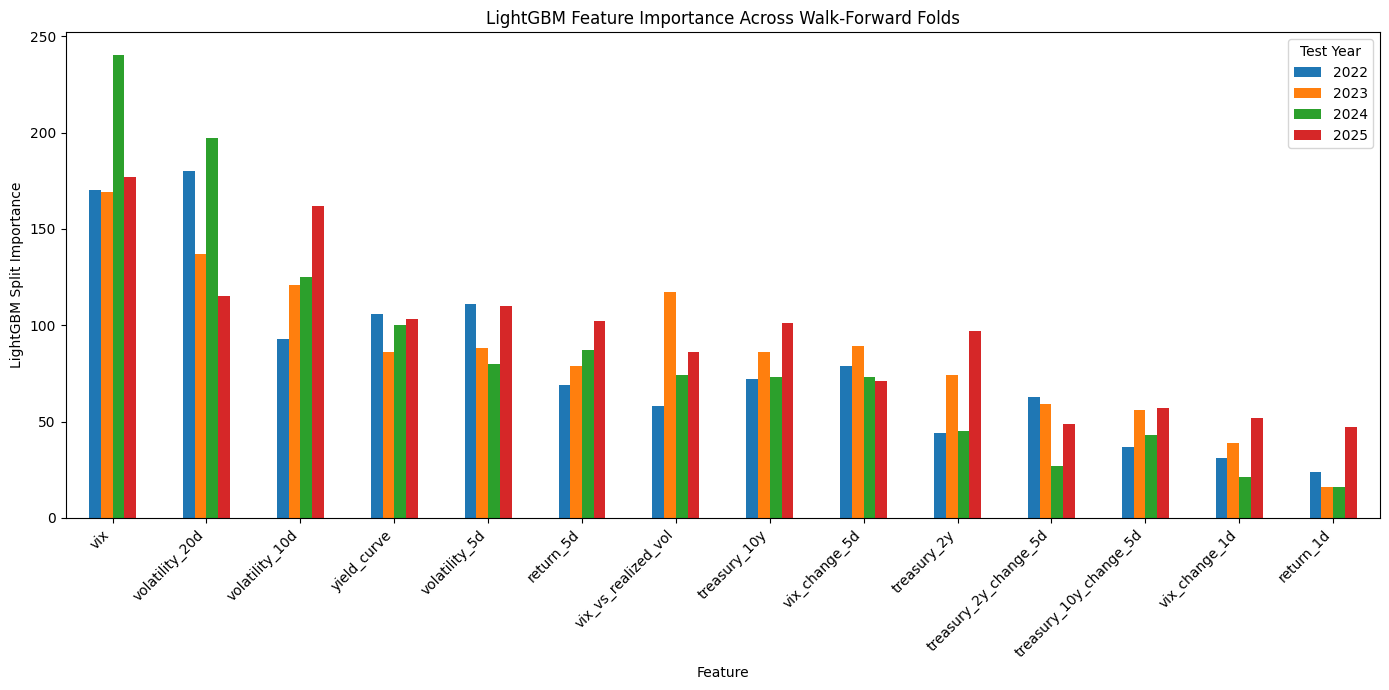

In [11]:
importance_pivot = feature_importances.pivot(
    index="feature",
    columns="test_year",
    values="importance",
)

importance_pivot["mean_importance"] = (
    importance_pivot.mean(axis=1)
)

importance_pivot = (
    importance_pivot
    .sort_values(
        "mean_importance",
        ascending=False,
    )
)

plot_data = importance_pivot.drop(
    columns="mean_importance"
)

plot_data.plot(
    kind="bar",
    figsize=(14, 7),
)

plt.xlabel("Feature")
plt.ylabel("LightGBM Split Importance")

plt.title(
    "LightGBM Feature Importance "
    "Across Walk-Forward Folds"
)

plt.xticks(
    rotation=45,
    ha="right",
)

plt.legend(title="Test Year")

plt.tight_layout()
plt.show()

### Plot LightGBM prediction vs realised volatility

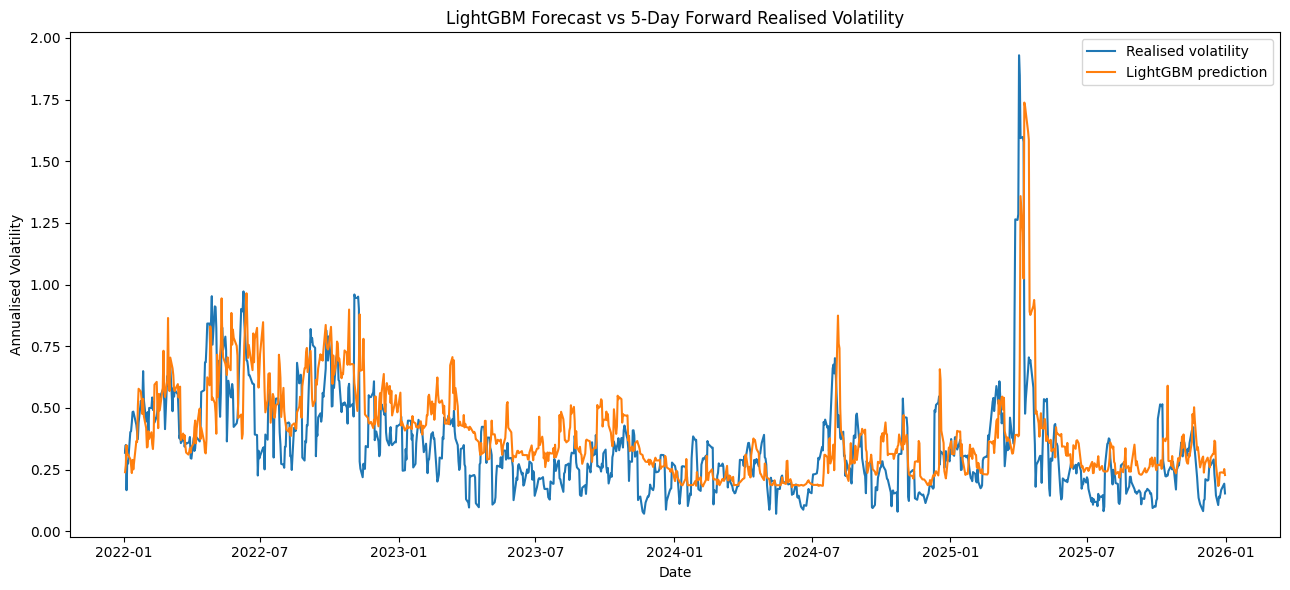

In [12]:
plt.figure(figsize=(13, 6))

plt.plot(
    predictions["date"],
    predictions["y_true"],
    label="Realised volatility",
)

plt.plot(
    predictions["date"],
    predictions["y_pred"],
    label="LightGBM prediction",
)

plt.xlabel("Date")
plt.ylabel("Annualised Volatility")

plt.title(
    "LightGBM Forecast vs "
    "5-Day Forward Realised Volatility"
)

plt.legend()

plt.tight_layout()
plt.show()

### Inspect largest LightGBM errors

In [21]:

largest_errors = (
    prediction_analysis
    .sort_values(
        "absolute_error",
        ascending=False,
    )
    .head(20)
)

largest_errors[
    [
        "date",
        "y_true",
        "y_pred",
        "error",
        "absolute_error",
        "vix",
        "volatility_5d",
        "volatility_20d",
        "return_5d",
    ]
]

,date,y_true,y_pred,error,absolute_error,vix,volatility_5d,volatility_20d,return_5d
814,2025-04-02,1.929532,0.389947,1.539585,1.539585,21.51,0.175264,0.198993,-0.007244
820,2025-04-10,0.476894,1.723109,-1.246215,1.246215,40.72,0.920100,0.482542,-0.024094
821,2025-04-11,0.538284,1.696204,-1.157921,1.157921,37.56,0.772198,0.480664,0.055445
815,2025-04-03,1.848132,0.698838,1.149294,1.149294,30.02,0.386781,0.256970,-0.053537
819,2025-04-09,0.734567,1.737819,-1.003252,1.003252,33.62,0.955048,0.469056,-0.038479
822,2025-04-14,0.655017,1.620084,-0.965067,0.965067,30.89,0.764363,0.481066,0.065693
813,2025-04-01,1.285469,0.384900,0.900570,0.900570,21.77,0.168803,0.201981,-0.025169
823,2025-04-15,0.705053,1.586282,-0.881229,0.881229,30.12,0.736765,0.480071,0.079789
811,2025-03-28,1.264605,0.390526,0.874079,0.874079,21.65,0.223832,0.209853,-0.015401
812,2025-03-31,1.262106,0.391264,0.870842,0.870842,22.28,0.162160,0.204703,-0.027370


In [14]:
model_data = pd.read_csv(
    "../data/processed/model_dataset.csv",
    parse_dates=["date"],
)

prediction_analysis = predictions.merge(
    model_data[
        [
            "date",
            "vix",
            "volatility_5d",
            "volatility_20d",
            "return_5d",
            "yield_curve",
        ]
    ],
    on="date",
    how="left",
)

In [15]:
largest_errors = (
    prediction_analysis
    .sort_values(
        "absolute_error",
        ascending=False,
    )
    .head(20)
)

largest_errors

,date,y_true,y_pred,error,absolute_error,vix,volatility_5d,volatility_20d,return_5d,yield_curve
814,2025-04-02,1.929532,0.389947,1.539585,1.539585,21.51,0.175264,0.198993,-0.007244,0.29
820,2025-04-10,0.476894,1.723109,-1.246215,1.246215,40.72,0.920100,0.482542,-0.024094,0.56
821,2025-04-11,0.538284,1.696204,-1.157921,1.157921,37.56,0.772198,0.480664,0.055445,0.52
815,2025-04-03,1.848132,0.698838,1.149294,1.149294,30.02,0.386781,0.256970,-0.053537,0.35
819,2025-04-09,0.734567,1.737819,-1.003252,1.003252,33.62,0.955048,0.469056,-0.038479,0.43
822,2025-04-14,0.655017,1.620084,-0.965067,0.965067,30.89,0.764363,0.481066,0.065693,0.54
813,2025-04-01,1.285469,0.384900,0.900570,0.900570,21.77,0.168803,0.201981,-0.025169,0.30
823,2025-04-15,0.705053,1.586282,-0.881229,0.881229,30.12,0.736765,0.480071,0.079789,0.51
811,2025-03-28,1.264605,0.390526,0.874079,0.874079,21.65,0.223832,0.209853,-0.015401,0.38
812,2025-03-31,1.262106,0.391264,0.870842,0.870842,22.28,0.162160,0.204703,-0.027370,0.34


## Compare Ridge and LightGBM predictions directly

In [18]:
ridge_predictions = pd.read_csv(
    "../results/ridge/ridge_predictions.csv",
    parse_dates=["date"],
)

ridge_predictions = ridge_predictions.rename(
    columns={
        "y_pred": "ridge_prediction",
    }
)

lightgbm_predictions = predictions.rename(
    columns={
        "y_pred": "lightgbm_prediction",
    }
)

In [19]:
comparison = ridge_predictions[
    [
        "date",
        "y_true",
        "ridge_prediction",
    ]
].merge(
    lightgbm_predictions[
        [
            "date",
            "lightgbm_prediction",
        ]
    ],
    on="date",
    how="inner",
)

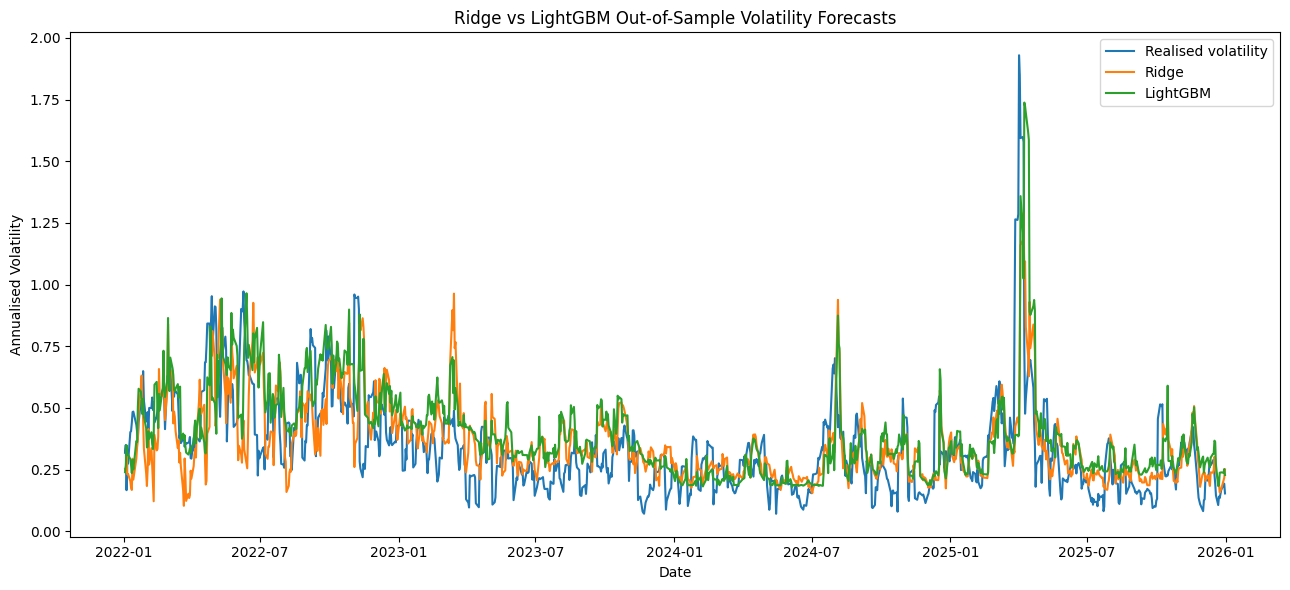

In [20]:
plt.figure(figsize=(13, 6))

plt.plot(
    comparison["date"],
    comparison["y_true"],
    label="Realised volatility",
)

plt.plot(
    comparison["date"],
    comparison["ridge_prediction"],
    label="Ridge",
)

plt.plot(
    comparison["date"],
    comparison["lightgbm_prediction"],
    label="LightGBM",
)

plt.xlabel("Date")
plt.ylabel("Annualised Volatility")

plt.title(
    "Ridge vs LightGBM "
    "Out-of-Sample Volatility Forecasts"
)

plt.legend()

plt.tight_layout()
plt.show()